In [2]:
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import scanpy as sc
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

from conv import *
from scState_model import *
from utils import *
import anndata as ad
from collections import Counter
import copy
import dill
from functools import partial
import json
import math
import multiprocessing as mp
import numpy as np
import os
import pandas as pd
from operator import itemgetter
import random
import scipy.sparse as sp
from scipy.io import mmread
from scipy.sparse import hstack, vstack, coo_matrix
import seaborn as sb
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import IncrementalPCA
from sklearn.decomposition import SparsePCA
from sklearn.metrics import accuracy_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import time
import torch
import torch.cuda as cuda
from torch import nn
from torch.autograd import Variable
import torch.distributions as D
import torch.nn.functional as F
import torch_geometric.data as Data
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.inits import glorot, uniform
from torch_geometric.utils import softmax as Softmax
from torchmetrics.functional import pairwise_cosine_similarity
import warnings
from warnings import filterwarnings
import xlwt
import argparse
from tqdm import tqdm
from scipy import sparse
from scipy.sparse import csc_matrix,csr_matrix

dataset_name = 'GSE147298_McSC'
batch_remove = False

filterwarnings("ignore")

parser = argparse.ArgumentParser(description='Training GNN on gene cell graph')
parser.add_argument('--seed', type=int, default=0)
parser.add_argument('--fi', type=int, default=0) # This parameter is used for the benchmark to specify the starting sequence number of the created files
parser.add_argument('--labsm', type=float, default=0.1) # The rate of LabelSmoothing
parser.add_argument('--wd', type=float, default=0.1) # The 'weight_decay' parameter is used to specify the strength of L2 regularization
parser.add_argument('--lr', type=float, default=0.0005) # learning rate 0.0005
parser.add_argument('--n_hid', type=int, default=104) # The number of layers should be a multiple of 'n_head' in order to make any modifications
parser.add_argument('--nheads', type=int, default=8) # The 'heads' parameter represents the number of attention heads in the attention mechanism
parser.add_argument('--nlayers', type=int, default=3) # The number of layers in network
parser.add_argument('--cell_size', type=int, default=30) # The number of cells per subgraph (batch)
parser.add_argument('--neighbor', type=int, default=20) # The number of neighboring nodes to be selected for each cell in the subgraph
parser.add_argument('--egrn', type=bool, default=False) # Whether to output the Enhancer-Gene regulatory network
parser.add_argument('--epochs', type=int, default=3) # The epoch number of NodeDimensionReduction
parser.add_argument('--num_epochs', type=int, default=3) # The epoch number of scState-Model
parser.add_argument('--output_file', type=str, default= f'Result/') # Please choose an output path to replace this path on your own.
args = parser.parse_args([])

output_file = args.output_file
fi=args.fi
labsm = args.labsm
lr = args.lr
wd = args.wd
n_hid = args.n_hid
nheads = args.nheads
nlayers = args.nlayers
cell_size = args.cell_size
neighbor = args.neighbor
egrn = args.egrn
epochs = args.epochs
num_epochs = args.num_epochs

seed = args.seed
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Read h5ad data as input
adata = sc.read_h5ad("Data/dataset_name_adata.h5ad")

In [4]:
import numpy as np
from scipy.sparse import csr_matrix

gene_names = adata.var_names.to_numpy()
cell_names = adata.obs_names.to_numpy()

X = adata.X

if isinstance(X, np.ndarray):
    RNA_matrix = csr_matrix(X.T)
else:
    RNA_matrix = X.T.tocsr()

GSVA = adata.obsm["GSVA"]
GSVA_matrix = GSVA.T
GSVA_matrix = csr_matrix(GSVA_matrix)

gepa_names = np.array(adata.uns["GSVA_pathways"])

In [5]:
# Pre-clustering
device = torch.device("cuda" if cuda.is_available() else "cpu")
print('You will use : ',device)
# clustering result by scanpy
if batch_remove:
    matrix = adata.obsm["RBE"]
else:
    matrix = RNA_matrix
initial_pre = initial_clustering(matrix, batch_remove=batch_remove) 
# number of every cluster
cluster_ini_num = len(set(initial_pre)) 
print(f'init cluster number is {cluster_ini_num}')
ini_p1 = [int(i) for i in initial_pre] 
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix, GSVA_matrix, neighbor = [neighbor], cell_size=cell_size)
n_batch = len(indices)

You will use :  cuda
	Using original count matrix for pre-clustering.
         Falling back to preprocessing with `sc.pp.pca` and default params.
init cluster number is 6
We are currently in the process of partitioning the data into batches. Kindly wait for a moment, please.


100%|██████████| 60/60 [00:53<00:00,  1.13it/s]


In [6]:
adata = run_palantir_pipeline(adata, ROI_genes=('Pax3', 'Sbno2', 'Bcl2'))

Determing nearest neighbor graph...
Sampling and flocking waypoints...
Time for determining waypoints: 0.0032861709594726564 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Raleway'] not 

Time for shortest paths: 0.37301982641220094 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [7]:
# Model node reduction training
node_model = NodeDimensionReduction(RNA_matrix, GSVA_matrix, indices, ini_p1, n_hid=n_hid, n_heads=nheads, 
                                    n_layers=nlayers,labsm=labsm, lr=lr, wd=wd, device=device, num_types=3, num_relations=2, epochs=250)
gnn, cell_embedding, cell_clu = node_model.train_model(n_batch=n_batch)

The training process for the NodeDimensionReduction model has started. Please wait.


100%|██████████| 250/250 [37:02<00:00,  8.89s/it]

The training for the NodeDimensionReduction model has been completed.


In [8]:
# Model training stage177
scState_stage1_model = scState_stage1(gnn=gnn, labsm=labsm, n_hid=n_hid, n_batch=n_batch, device=device,lr=lr,palantir_pseudotime=np.array(adata.obs['palantir_pseudotime']), Node_Ids=Node_Ids, wd=wd, num_epochs=50)
scState_gnn_stage1, is_stem_mask, cell_embedding, stem_like_clus = scState_stage1_model.train_model(indices=indices,RNA_matrix=RNA_matrix, GSVA_matrix=GSVA_matrix, ini_p1=ini_p1)

The training process for the scState model has started. Please wait.
The 0 epoch


100%|██████████| 60/60 [00:05<00:00, 11.00it/s]


The 1 epoch


100%|██████████| 60/60 [00:04<00:00, 13.39it/s]


The 2 epoch


...

The 48 epoch


100%|██████████| 60/60 [00:04<00:00, 14.18it/s]


The 49 epoch


100%|██████████| 60/60 [00:04<00:00, 14.20it/s]


The training for the scState model has been completed.


In [31]:
# Model training stage2
prototype_indicies, labeled_target_data, stem_labels_torch, gmm_ratio = stage2_initial_clustering(GSVA_matrix, Node_Ids, is_stem_mask, device)
scState_stage2_model = scState_stage2(gnn=scState_gnn_stage1, labsm=labsm, n_hid=n_hid, n_batch=n_batch, device=device,lr=lr,Node_Ids=Node_Ids, wd=wd, cell_embedding=cell_embedding, prototype_indicies=prototype_indicies, is_stem_mask=is_stem_mask, stem_pseudo_labels=stem_labels_torch, labeled_target_data=labeled_target_data, gmm_ratio=gmm_ratio, indices=indices,RNA_matrix=RNA_matrix, GSVA_matrix=GSVA_matrix, num_epochs=200)
scState_gnn_stage2, prototypes = scState_stage2_model.train_model(indices=indices,RNA_matrix=RNA_matrix, GSVA_matrix=GSVA_matrix, ini_p1=ini_p1)

# The result of scState
scState_result = scState_pred_stage2(RNA_matrix, GSVA_matrix, egrn=egrn, scState_gnn=scState_gnn_stage2, indices=indices, 
                    nodes_id=Node_Ids, cell_size=cell_size, device=device, gene_names=gene_names, gepa_names=gepa_names, stem_clu=stem_like_clus, prototypes=prototypes)

The training process for the scState model has started. Please wait.


100%|██████████| 200/200 [22:09<00:00,  6.65s/it]


The training for the scState model has been completed.


In [32]:
nodes_id = list(Node_Ids)
pred_label = list(scState_result['pred_label'])
cell_embedding = scState_result['cell_embedding']

# Save numpy arrays to files
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", scState_result['pred_label'])
np.save(output_file + "/cell_embedding.npy", scState_result['cell_embedding'])

In [33]:
# pred_label，cell_embedding，nodes_id
nodes_id = list(np.load(output_file + "/Node_Ids.npy"))
pred_label = list(np.load(output_file + "/pred.npy"))
cell_embedding = np.load(output_file + "/cell_embedding.npy")

In [34]:
import pandas as pd
import numpy as np

old_labels = np.array(pred_label).astype(int)

# 105 → McSC_1 106 → McSC_1
special_map = {105: "McSC_1", 106: "McSC_2"}
normal = sorted([x for x in np.unique(old_labels) if x not in special_map])
normal_map = {old: new for new, old in enumerate(normal)}
final_map = {**normal_map, **special_map}

new_labels = [final_map[x] for x in old_labels]

最终映射： {0: 0, 2: 1, 3: 2, 4: 3, 5: 4, 105: 'McSC_1', 106: 'McSC_2'}


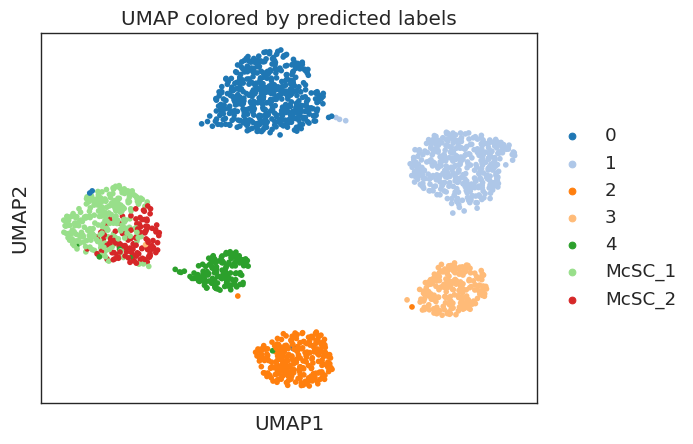

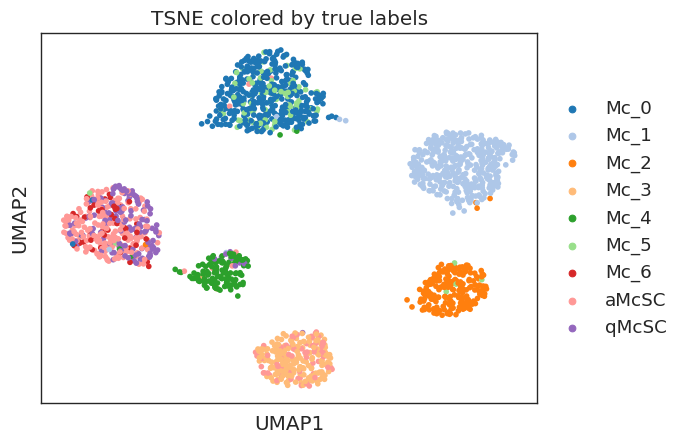

In [35]:
%matplotlib inline

adata_plot = sc.AnnData(cell_embedding)
adata_plot.obs_names = cell_names[nodes_id]

adata_plot.obs['pred_label'] = pd.Categorical(new_labels)
adata_plot.obs['label'] = pd.Categorical(list(adata.obs['true_label'].values))[nodes_id]

sc.pp.neighbors(adata_plot, use_rep='X')
sc.tl.umap(adata_plot)
import seaborn as sns
palette = sns.color_palette("tab20") 
sc.pl.umap(adata_plot, color='pred_label', palette=palette, title='UMAP colored by predicted labels')
sc.pl.umap(adata_plot, color='label', palette=palette, title='TSNE colored by true labels')

In [36]:
gsva_go = pd.read_csv(f"/fs/ess/PAS1475/wangxiaoying/Lxue/study_bioinformatics/SparsGT/Rcode/GSVA/GSVA_result/{dataset_name}_GSVA_GO.csv", index_col=0)
gsva_go_aligned = gsva_go.loc[:, adata_plot.obs_names]

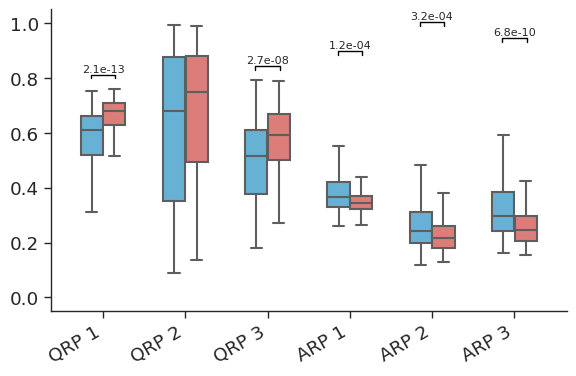

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

# ========== Cell grouping ==========
cells_q = adata_plot.obs[adata_plot.obs["pred_label"] == 'McSC_1'].index
cells_a = adata_plot.obs[adata_plot.obs["pred_label"] == 'McSC_2'].index

rank_df = gsva_go_aligned.rank(axis=0, method='average', ascending=False)
percentile_df = 1 - (rank_df - 1) / (gsva_go_aligned.shape[0] - 1)

# ========== Relative pathways ==========
path_set1 = [
    "GOBP_CELL_CELL_ADHESION",
    "GOBP_NEGATIVE_REGULATION_OF_CELL_FATE_COMMITMENT",
    "GOBP_ANATOMICAL_STRUCTURE_HOMEOSTASIS"
]

path_set2 = [
    "GOBP_CELL_CYCLE",
    "GOBP_DNA_REPLICATION",
    "GOBP_DNA_REPAIR"
]

all_paths = path_set1 + path_set2

plot_df = percentile_df.loc[all_paths]

df_long = plot_df.melt(ignore_index=False, var_name="cell", value_name="score")
df_long["pathway"] = df_long.index.get_level_values(0)

df_long["cell_type"] = df_long["cell"].apply(
    lambda x: "qMcSC" if x in cells_q else ("aMcSC" if x in cells_a else "other")
)

df_long = df_long[df_long["cell_type"] != "other"]

pathway_map = {
    "GOBP_CELL_CELL_ADHESION": "QRP 1",
    "GOBP_NEGATIVE_REGULATION_OF_CELL_FATE_COMMITMENT": "QRP 2",
    "GOBP_ANATOMICAL_STRUCTURE_HOMEOSTASIS": "QRP 3",
    "GOBP_CELL_CYCLE": "ARP 1",
    "GOBP_DNA_REPLICATION": "ARP 2",
    "GOBP_DNA_REPAIR": "ARP 3",
}

df_long["pathway"] = df_long["pathway"].map(pathway_map)

order_hue = ["qMcSC", "aMcSC"]

from scipy.stats import mannwhitneyu
import numpy as np

# ========== Significance Test ============
def mannwhitney_significance(df_long):
    results = {}

    for pathway in df_long["pathway"].unique():
        data_q = df_long[
            (df_long["pathway"] == pathway) &
            (df_long["cell_type"] == "qMcSC")
        ]["score"]

        data_a = df_long[
            (df_long["pathway"] == pathway) &
            (df_long["cell_type"] == "aMcSC")
        ]["score"]

        if len(data_q) > 1 and len(data_a) > 1:
            u_stat, p_value = mannwhitneyu(
                data_q, data_a, alternative="two-sided"
            )

            if p_value < 0.001:
                symbol = f"{p_value:.1e}"
            elif p_value < 0.01:
                symbol = f"{p_value:.1e}"
            elif p_value < 0.05:
                symbol = f"{p_value:.1e}"
            else:
                symbol = "ns"

            results[pathway] = {
                "p_value": p_value,
                "symbol": symbol,
                "n_q": len(data_q),
                "n_a": len(data_a),
                "median_q": np.median(data_q),
                "median_a": np.median(data_a),
                "method": "Wilcoxon rank-sum (Mann–Whitney U)"
            }
        else:
            results[pathway] = {
                "p_value": None,
                "symbol": "NA",
                "n_q": len(data_q),
                "n_a": len(data_a)
            }

    return results


sig_results = mannwhitney_significance(df_long)

import seaborn as sns

plt.figure(figsize=(6, 4))

ax = sns.boxplot(
    data=df_long,
    x="pathway",
    y="score",
    hue="cell_type",
    hue_order=["qMcSC", "aMcSC"],
    palette={"qMcSC": "#55b7e6", "aMcSC": "#ed6e69"},
    width=0.55,
    dodge=0.2,
    showfliers=False,
    linewidth=1.5
)

ax.get_legend().remove()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=30, ha="right")
plt.ylim(-0.05, 1.05)


def add_mannwhitney_stars(ax, df_long, sig_results, offset=0.04):
    pathways = list(df_long["pathway"].unique())

    for i, pathway in enumerate(pathways):
        result = sig_results.get(pathway, None)
        if result is None or result["symbol"] in ["ns", "NA"]:
            continue

        data_q = df_long[
            (df_long["pathway"] == pathway) &
            (df_long["cell_type"] == "qMcSC")
        ]["score"]

        data_a = df_long[
            (df_long["pathway"] == pathway) &
            (df_long["cell_type"] == "aMcSC")
        ]["score"]

        y_max = max(data_q.max(), data_a.max())
        y = y_max + offset

        x1, x2 = i - 0.15, i + 0.15

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + offset*0.3, y + offset*0.3, y],
            lw=1,
            c="black"
        )

        ax.text(
            i,
            y + offset*0.4,
            result["symbol"],
            ha="center",
            va="bottom",
            fontsize=8
        )


add_mannwhitney_stars(ax, df_long, sig_results)
plt.tight_layout()
plt.show()